# Popularity baseline on quarterly splits
Goal: Starting with train data covering 2003-2006 and then incrementing data in quarters, we provide recommendations for the next quarter based on popularity. 

To run before running this: `scripts/download_data.py` and `scripts/make_splits.py`

In [11]:
# optional if you have trouble running the environments
import sys
sys.path.insert(0, "../src")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from remy.splits import RollingSplits, SPLIT_DIR
from remy.model.popularity import Popularity
from remy.evaluate import evaluate_quarter

In [13]:
splits = RollingSplits()
split = "val"

splits.windows.groupby("split", sort=False)[
    ["outcome_reviews", "positive_reviews", "positive_users"]
].sum().rename(columns={"positive_users": "positive_user_quarters"})

,outcome_reviews,positive_reviews,positive_user_quarters
split,,,
train,138126,106422,19880
val,377717,279537,61814
test,134059,100846,29079


## Fit and evaluate the popularity model

For each of the 16 evaluation quarters from 2007-2010, provide the model with:
- quarter history: all interactions before the validation start date
- recipes: all recipes from interactions before the validation start date
- training quarters: list of all historical splits, unused in this model since we do not need to learn any features or labels

Then, evaluate the model on that quarter's validation data. Finally, report average numbers for each metric. 

In [14]:
rows = []
for quarter in splits.evaluation_quarters(split):
    model = Popularity()
    model.fit(
        quarter.history,
        recipes=quarter.recipes,
        training_quarters=splits.training_quarters(quarter.start)
    )
    # Current outcomes are used only for scoring, after the fit.
    rows.append(evaluate_quarter(quarter, model.ranking_, model.seen_))

results = pd.DataFrame(rows)
results.to_csv(SPLIT_DIR / f"popularity_{split}.csv", index=False)
results[["NDCG", "HR@10", "HR@100", "Recall@10", "Recall@100"]].mean().to_frame("Mean across quarters").round(4)

,Mean across quarters
NDCG,0.1251
HR@10,0.0398
HR@100,0.1604
Recall@10,0.0157
Recall@100,0.0703


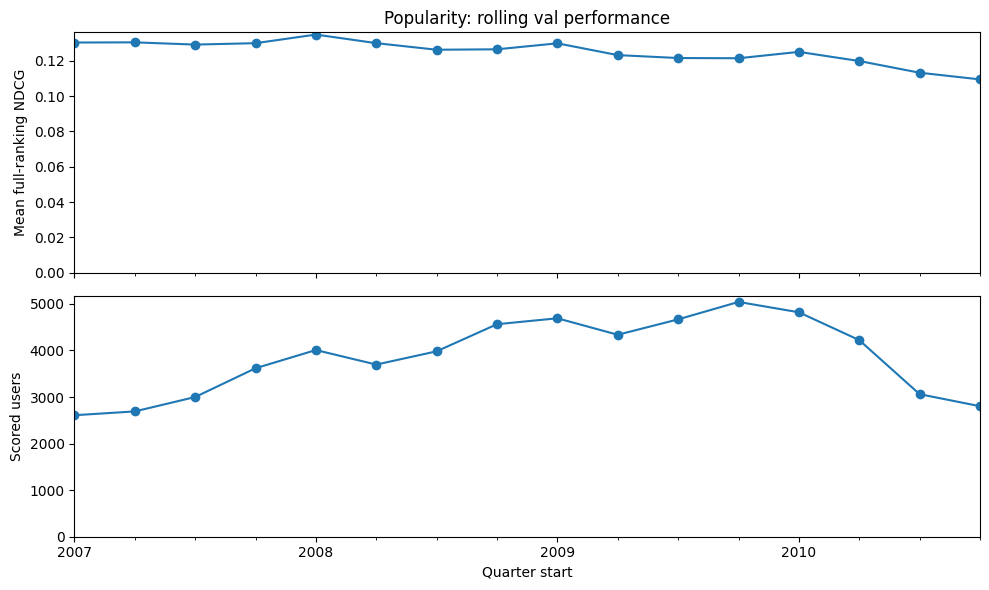

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
results.plot(x="start", y="NDCG", marker="o", legend=False, ax=axes[0])
axes[0].set(title=f"Popularity: rolling {split} performance", ylabel="Mean full-ranking NDCG")
axes[0].set_ylim(bottom=0)
results.plot(x="start", y="scored_users", marker="o", legend=False, ax=axes[1])
axes[1].set(ylabel="Scored users", xlabel="Quarter start")
axes[1].set_ylim(bottom=0)
fig.tight_layout()
plt.show()

The all-time ranking includes winter comfort foods (pot roast, chicken pot pie, potato soup) and some Christmas-tagged baking recipes, so it plausibly matches winter demand better than spring/summer demand. The first-quarter increases are consistent with that explanation, but do not establish the cause.

These scores describe active, eligible users, not every visitor; the second chart shows how that population changes. Below are the most-reviewed recipes at the **last checkpoint**, before each user's seen recipes are removed.

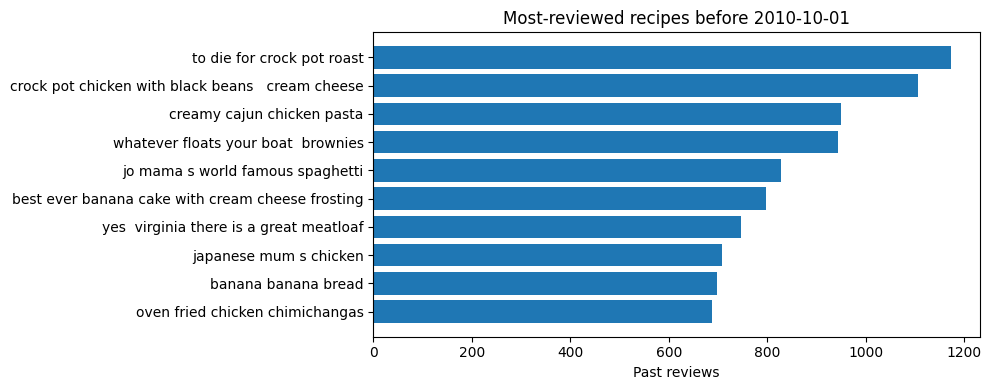

In [16]:
top = model.scores_.head(10).sort_values()
names = quarter.recipes.set_index("id")["name"]
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(names.reindex(top.index), top.values)
ax.set(title=f"Most-reviewed recipes before {quarter.start.date()}", xlabel="Past reviews")
fig.tight_layout()
plt.show()